In [ ]:
# Goal:
# Compare CHMv1, CHMv2 minimal, and CHMv2 standardized for pole vegetation analysis
# using a 2 meter radius around each pole.

# Risk rule used here:
# A pole is marked "risk" if the maximum canopy height within 2 meters of the pole
# is greater than or equal to the assumed pole height.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.transform import rowcol
from rasterio.warp import transform
from matplotlib.lines import Line2D


In [ ]:
csv_path = Path("/content/drive/MyDrive/electric-pole-analysis/reference/matched_rows_only_pole_vegetation_streetview.csv")

chmv1_path = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/chmv1_rgb3_alpha_nodata255_res060_chm.tif")
chmv2_min_path = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/chmv2_minimal_tile512_ov64.tif")
chmv2_std_path = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/chmv2_standardized_tile512_ov64.tif")

rgb_native_path = Path("/content/drive/MyDrive/electric-pole-analysi/inputs/rgb3_alpha_native.tif")
rgb_std_path = Path("/content/drive/MyDrive/electric-pole-analysi/inputs/rgb3_alpha_nodata255_res060.tif")

for p in [csv_path, chmv1_path, chmv2_min_path, chmv2_std_path, rgb_native_path, rgb_std_path]:
    print(p.name, "->", p.exists())


matched_rows_only_pole_vegetation_streetview.csv -> True
chmv1_rgb3_alpha_nodata255_res060_chm.tif -> True
chmv2_minimal_tile512_ov64.tif -> True
chmv2_standardized_tile512_ov64.tif -> True
rgb3_alpha_native.tif -> True
rgb3_alpha_nodata255_res060.tif -> True


In [ ]:
RADIUS_M = 2.0
POLE_HEIGHT_FT = 30.0
POLE_HEIGHT_M = POLE_HEIGHT_FT * 0.3048

print("Radius (m):", RADIUS_M)
print("Pole height (ft):", POLE_HEIGHT_FT)
print("Pole height (m):", POLE_HEIGHT_M)


Radius (m): 2.0
Pole height (ft): 30.0
Pole height (m): 9.144


In [ ]:
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Shape: (319, 16)
Columns: ['pole_id', 'image_name', 'veg_id', 'veg_name', 'comment', 'labeled_at', 'objectid', 'elt_id', 'pole_lat', 'pole_lng', 'sv_status', 'pano_id', 'sv_date', 'sv_lat', 'sv_lng', 'copyright']


,pole_id,image_name,veg_id,veg_name,comment,labeled_at,objectid,elt_id,pole_lat,pole_lng,sv_status,pano_id,sv_date,sv_lat,sv_lng,copyright
0,38.971930_-77.057118,38.971930_-77.057118.jpg,3,critical,NaN,2026-02-24T10:53:07,41451,2583,38.971930,-77.057118,OK,rVYhqRB4nhTEqNZbngf7Sg,2025-10,38.971957,-77.057194,© Google
1,38.971930_-77.060122,38.971930_-77.060122.jpg,0,clear,As the pole and the tree/vegetation is far awa...,2026-02-24T10:54:41,50925,7468,38.971930,-77.060122,OK,t-9WpFk496NIxj0mGpuIKA,2025-08,38.971592,-77.060489,© Google
2,38.971936_-77.057288,38.971936_-77.057288.jpg,0,clear,The pole is horizontally farway from the veget...,2026-02-24T11:01:20,31948,2719,38.971936,-77.057288,OK,jXNU1hWyoUzSmwDX5as9Pw,2025-10,38.971891,-77.057278,© Google
3,38.971966_-77.059086,38.971966_-77.059086.jpg,3,critical,The pole is horizontally farway from the veget...,2026-02-24T11:01:34,47735,7253,38.971966,-77.059086,OK,qIKTMQB2SAjdiJq_GlbfYw,2025-08,38.971964,-77.059175,© Google
4,38.972012_-77.065174,38.972012_-77.065174.jpg,3,critical,The pole is horizontally farway from the veget...,2026-02-24T11:01:51,63600,8318,38.972012,-77.065174,OK,Zm3YbTWPIn3d8QNjNaIvuQ,2025-08,38.972052,-77.065114,© Google


In [ ]:
def classify_manual_risk(row):
    veg_id = row["veg_id"]
    veg_name = str(row["veg_name"]).strip().lower()

    if veg_id == 0 or veg_name in {"clear", "safe"}:
        return "safe"
    if veg_id in {1, 2, 3} or veg_name in {"high", "watch", "critical", "risk"}:
        return "risk"
    return "unknown"

df["manual_risk"] = df.apply(classify_manual_risk, axis=1)
df["pole_height_ft"] = POLE_HEIGHT_FT
df["pole_height_m"] = POLE_HEIGHT_M

df[["pole_id", "veg_id", "veg_name", "manual_risk", "pole_height_ft", "pole_height_m"]].head()


,pole_id,veg_id,veg_name,manual_risk,pole_height_ft,pole_height_m
0,38.971930_-77.057118,3,critical,risk,30.0,9.144
1,38.971930_-77.060122,0,clear,safe,30.0,9.144
2,38.971936_-77.057288,0,clear,safe,30.0,9.144
3,38.971966_-77.059086,3,critical,risk,30.0,9.144
4,38.972012_-77.065174,3,critical,risk,30.0,9.144


In [ ]:
with rasterio.open(chmv1_path) as src:
    chmv1 = src.read(1)
    chmv1_transform = src.transform
    chmv1_crs = src.crs

with rasterio.open(chmv2_min_path) as src:
    chmv2_min = src.read(1)
    chmv2_min_transform = src.transform
    chmv2_min_crs = src.crs

with rasterio.open(chmv2_std_path) as src:
    chmv2_std = src.read(1)
    chmv2_std_transform = src.transform
    chmv2_std_crs = src.crs

with rasterio.open(rgb_native_path) as src:
    rgb_native = np.moveaxis(src.read([1, 2, 3]), 0, -1)
    rgb_native_transform = src.transform
    rgb_native_crs = src.crs

with rasterio.open(rgb_std_path) as src:
    rgb_std = np.moveaxis(src.read([1, 2, 3]), 0, -1)
    rgb_std_transform = src.transform
    rgb_std_crs = src.crs

print("CHMv1 shape:", chmv1.shape, "CRS:", chmv1_crs)
print("CHMv2 minimal shape:", chmv2_min.shape, "CRS:", chmv2_min_crs)
print("CHMv2 standardized shape:", chmv2_std.shape, "CRS:", chmv2_std_crs)


CHMv1 shape: (2330, 2194) CRS: EPSG:32618
CHMv2 minimal shape: (2796, 2632) CRS: EPSG:32618
CHMv2 standardized shape: (2330, 2194) CRS: EPSG:32618


In [ ]:
xs, ys = transform(
    "EPSG:4326",
    chmv1_crs,
    df["pole_lng"].tolist(),
    df["pole_lat"].tolist(),
)

df["x_utm"] = xs
df["y_utm"] = ys

df[["pole_id", "pole_lat", "pole_lng", "x_utm", "y_utm"]].head()


,pole_id,pole_lat,pole_lng,x_utm,y_utm
0,38.971930_-77.057118,38.971930,-77.057118,321792.140912,4.315674e+06
1,38.971930_-77.060122,38.971930,-77.060122,321531.806869,4.315680e+06
2,38.971936_-77.057288,38.971936,-77.057288,321777.428588,4.315675e+06
3,38.971966_-77.059086,38.971966,-77.059086,321621.725846,4.315682e+06
4,38.972012_-77.065174,38.972012,-77.065174,321094.321090,4.315699e+06


In [ ]:
def prepare_rgb_display(rgb, nodata_value=None, invalid_white=False):
    out = rgb.astype(np.float32).copy()

    for b in range(3):
        if nodata_value is None:
            valid = out[..., b] > 0
        else:
            valid = out[..., b] != nodata_value

        if valid.any():
            p2, p98 = np.percentile(out[..., b][valid], (2, 98))
            if p98 > p2:
                out[..., b] = np.clip((out[..., b] - p2) / (p98 - p2), 0, 1)

    if invalid_white and nodata_value is not None:
        invalid = np.any(rgb == nodata_value, axis=-1)
        out[invalid] = [1, 1, 1]

    return out


In [ ]:
def extract_buffer_stats(arr, transform_obj, x, y, radius_m, pole_height_m):
    row, col = rowcol(transform_obj, x, y)

    if row < 0 or col < 0 or row >= arr.shape[0] or col >= arr.shape[1]:
        return {
            "center_row": row,
            "center_col": col,
            "buffer_valid_count": 0,
            "buffer_max_m": np.nan,
            "buffer_mean_m": np.nan,
            "buffer_p95_m": np.nan,
            "buffer_above_pole_count": 0,
            "buffer_above_pole_pct": np.nan,
            "buffer_risk": "no_data",
        }

    pixel_size_x = abs(transform_obj.a)
    pixel_size_y = abs(transform_obj.e)

    row_radius = int(np.ceil(radius_m / pixel_size_y))
    col_radius = int(np.ceil(radius_m / pixel_size_x))

    r0 = max(0, row - row_radius)
    r1 = min(arr.shape[0], row + row_radius + 1)
    c0 = max(0, col - col_radius)
    c1 = min(arr.shape[1], col + col_radius + 1)

    window = arr[r0:r1, c0:c1]

    rows = np.arange(r0, r1)
    cols = np.arange(c0, c1)
    rr, cc = np.meshgrid(rows, cols, indexing="ij")

    xs = transform_obj.c + (cc + 0.5) * transform_obj.a
    ys = transform_obj.f + (rr + 0.5) * transform_obj.e

    dist = np.sqrt((xs - x) ** 2 + (ys - y) ** 2)
    inside = dist <= radius_m
    valid = inside & np.isfinite(window)

    if not valid.any():
        return {
            "center_row": row,
            "center_col": col,
            "buffer_valid_count": 0,
            "buffer_max_m": np.nan,
            "buffer_mean_m": np.nan,
            "buffer_p95_m": np.nan,
            "buffer_above_pole_count": 0,
            "buffer_above_pole_pct": np.nan,
            "buffer_risk": "no_data",
        }

    vals = window[valid]
    above_count = int(np.sum(vals >= pole_height_m))
    total_valid = int(vals.size)

    return {
        "center_row": row,
        "center_col": col,
        "buffer_valid_count": total_valid,
        "buffer_max_m": float(np.nanmax(vals)),
        "buffer_mean_m": float(np.nanmean(vals)),
        "buffer_p95_m": float(np.nanpercentile(vals, 95)),
        "buffer_above_pole_count": above_count,
        "buffer_above_pole_pct": 100 * above_count / total_valid,
        "buffer_risk": "risk" if float(np.nanmax(vals)) >= pole_height_m else "safe",
    }


In [ ]:
results_chmv1 = []
results_chmv2_min = []
results_chmv2_std = []

for _, row in df.iterrows():
    x = row["x_utm"]
    y = row["y_utm"]

    results_chmv1.append(
        extract_buffer_stats(chmv1, chmv1_transform, x, y, RADIUS_M, POLE_HEIGHT_M)
    )
    results_chmv2_min.append(
        extract_buffer_stats(chmv2_min, chmv2_min_transform, x, y, RADIUS_M, POLE_HEIGHT_M)
    )
    results_chmv2_std.append(
        extract_buffer_stats(chmv2_std, chmv2_std_transform, x, y, RADIUS_M, POLE_HEIGHT_M)
    )


In [ ]:
for prefix, results in [
    ("chmv1", results_chmv1),
    ("chmv2_min", results_chmv2_min),
    ("chmv2_std", results_chmv2_std),
]:
    tmp = pd.DataFrame(results)
    tmp.columns = [f"{prefix}_{c}" for c in tmp.columns]
    df = pd.concat([df.reset_index(drop=True), tmp.reset_index(drop=True)], axis=1)

df.head()


,pole_id,image_name,veg_id,veg_name,comment,labeled_at,objectid,elt_id,pole_lat,pole_lng,...,chmv2_min_buffer_risk,chmv2_std_center_row,chmv2_std_center_col,chmv2_std_buffer_valid_count,chmv2_std_buffer_max_m,chmv2_std_buffer_mean_m,chmv2_std_buffer_p95_m,chmv2_std_buffer_above_pole_count,chmv2_std_buffer_above_pole_pct,chmv2_std_buffer_risk
0,38.971930_-77.057118,38.971930_-77.057118.jpg,3,critical,NaN,2026-02-24T10:53:07,41451,2583,38.971930,-77.057118,...,no_data,2463,1376,0,NaN,NaN,NaN,0,NaN,no_data
1,38.971930_-77.060122,38.971930_-77.060122.jpg,0,clear,As the pole and the tree/vegetation is far awa...,2026-02-24T10:54:41,50925,7468,38.971930,-77.060122,...,no_data,2453,943,0,NaN,NaN,NaN,0,NaN,no_data
2,38.971936_-77.057288,38.971936_-77.057288.jpg,0,clear,The pole is horizontally farway from the veget...,2026-02-24T11:01:20,31948,2719,38.971936,-77.057288,...,no_data,2461,1352,0,NaN,NaN,NaN,0,NaN,no_data
3,38.971966_-77.059086,38.971966_-77.059086.jpg,3,critical,The pole is horizontally farway from the veget...,2026-02-24T11:01:34,47735,7253,38.971966,-77.059086,...,no_data,2449,1092,0,NaN,NaN,NaN,0,NaN,no_data
4,38.972012_-77.065174,38.972012_-77.065174.jpg,3,critical,The pole is horizontally farway from the veget...,2026-02-24T11:01:51,63600,8318,38.972012,-77.065174,...,no_data,2421,213,0,NaN,NaN,NaN,0,NaN,no_data


In [ ]:
preview_cols = [
    "pole_id",
    "manual_risk",
    "pole_height_m",
    "chmv1_buffer_max_m",
    "chmv1_buffer_risk",
    "chmv2_min_buffer_max_m",
    "chmv2_min_buffer_risk",
    "chmv2_std_buffer_max_m",
    "chmv2_std_buffer_risk",
]

df[preview_cols].head(10)


,pole_id,manual_risk,pole_height_m,chmv1_buffer_max_m,chmv1_buffer_risk,chmv2_min_buffer_max_m,chmv2_min_buffer_risk,chmv2_std_buffer_max_m,chmv2_std_buffer_risk
0,38.971930_-77.057118,risk,9.144,NaN,no_data,NaN,no_data,NaN,no_data
1,38.971930_-77.060122,safe,9.144,NaN,no_data,NaN,no_data,NaN,no_data
2,38.971936_-77.057288,safe,9.144,NaN,no_data,NaN,no_data,NaN,no_data
3,38.971966_-77.059086,risk,9.144,NaN,no_data,NaN,no_data,NaN,no_data
4,38.972012_-77.065174,risk,9.144,NaN,no_data,NaN,no_data,NaN,no_data
5,38.972013_-77.067435,risk,9.144,NaN,no_data,NaN,no_data,NaN,no_data
6,38.972014_-77.067824,risk,9.144,NaN,no_data,NaN,no_data,NaN,no_data
7,38.972014_-77.069040,safe,9.144,NaN,no_data,NaN,no_data,NaN,no_data
8,38.972025_-77.062445,risk,9.144,NaN,no_data,NaN,no_data,NaN,no_data
9,38.972077_-77.056924,risk,9.144,NaN,no_data,NaN,no_data,NaN,no_data


/tmp/ipykernel_29401/3245647717.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


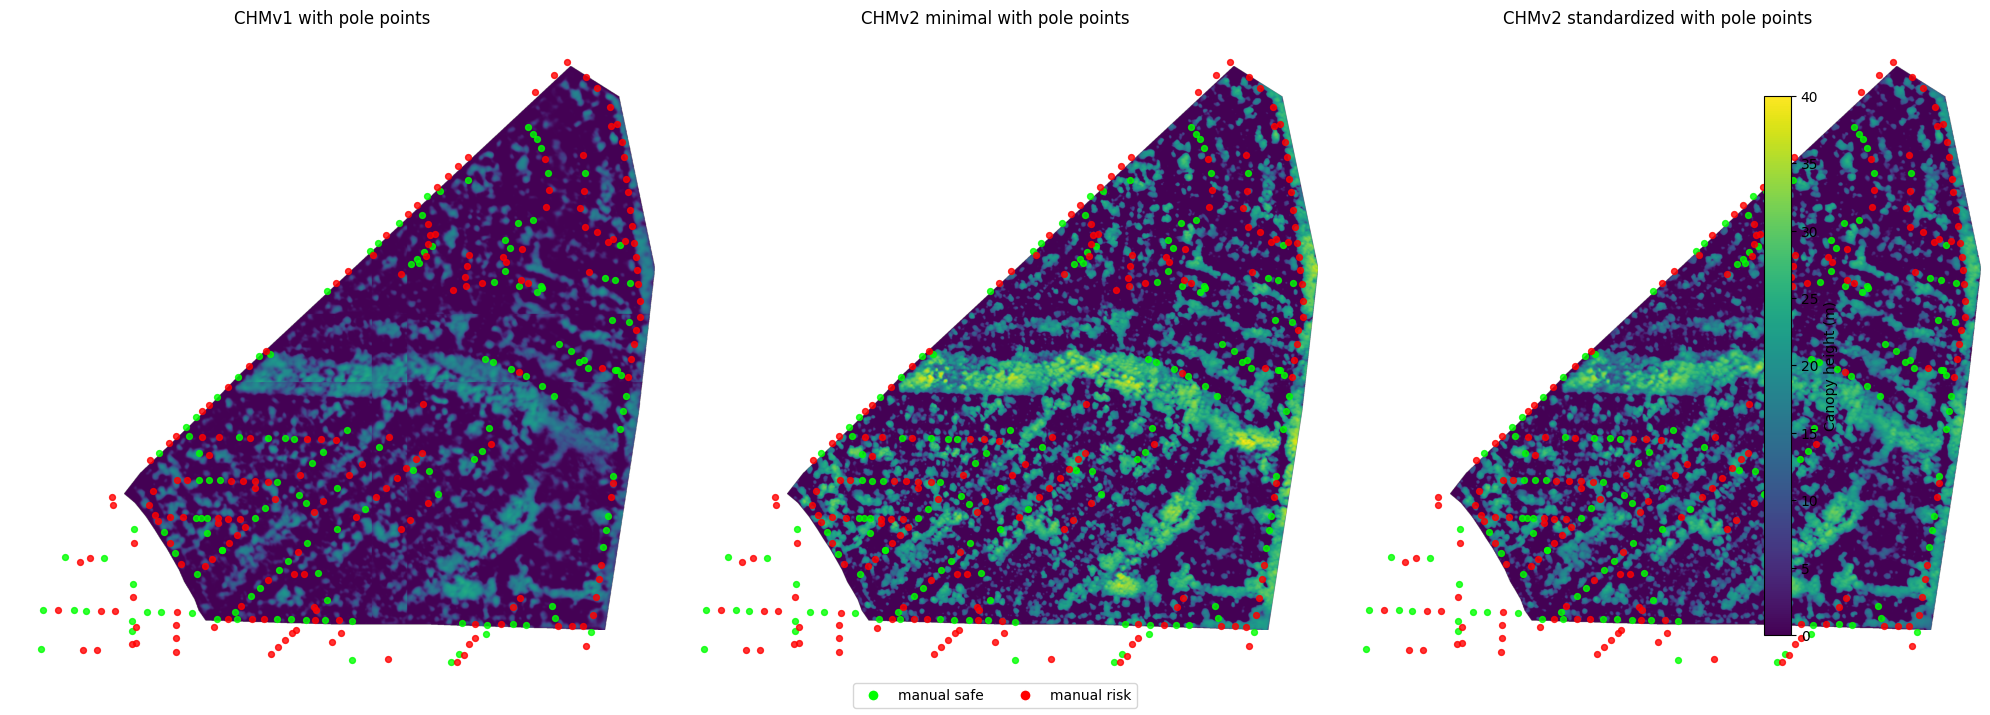

In [ ]:
safe_mask = df["manual_risk"] == "safe"
risk_mask = df["manual_risk"] == "risk"

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(chmv1, cmap="viridis", vmin=0, vmax=40)
axes[0].scatter(df.loc[safe_mask, "chmv1_center_col"], df.loc[safe_mask, "chmv1_center_row"], s=18, c="lime", alpha=0.8)
axes[0].scatter(df.loc[risk_mask, "chmv1_center_col"], df.loc[risk_mask, "chmv1_center_row"], s=18, c="red", alpha=0.8)
axes[0].set_title("CHMv1 with pole points")
axes[0].axis("off")

axes[1].imshow(chmv2_min, cmap="viridis", vmin=0, vmax=40)
axes[1].scatter(df.loc[safe_mask, "chmv2_min_center_col"], df.loc[safe_mask, "chmv2_min_center_row"], s=18, c="lime", alpha=0.8)
axes[1].scatter(df.loc[risk_mask, "chmv2_min_center_col"], df.loc[risk_mask, "chmv2_min_center_row"], s=18, c="red", alpha=0.8)
axes[1].set_title("CHMv2 minimal with pole points")
axes[1].axis("off")

im = axes[2].imshow(chmv2_std, cmap="viridis", vmin=0, vmax=40)
axes[2].scatter(df.loc[safe_mask, "chmv2_std_center_col"], df.loc[safe_mask, "chmv2_std_center_row"], s=18, c="lime", alpha=0.8)
axes[2].scatter(df.loc[risk_mask, "chmv2_std_center_col"], df.loc[risk_mask, "chmv2_std_center_row"], s=18, c="red", alpha=0.8)
axes[2].set_title("CHMv2 standardized with pole points")
axes[2].axis("off")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='manual safe', markerfacecolor='lime', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='manual risk', markerfacecolor='red', markersize=8),
]

fig.legend(handles=legend_elements, loc="lower center", ncol=2)
plt.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="Canopy height (m)")
plt.tight_layout()
plt.show()


In [ ]:
valid_manual = {"risk", "safe"}
valid_model = {"risk", "safe"}

df_eval_chmv1 = df[
    df["manual_risk"].isin(valid_manual) &
    df["chmv1_buffer_risk"].isin(valid_model)
].copy()

df_eval_chmv2_min = df[
    df["manual_risk"].isin(valid_manual) &
    df["chmv2_min_buffer_risk"].isin(valid_model)
].copy()

df_eval_chmv2_std = df[
    df["manual_risk"].isin(valid_manual) &
    df["chmv2_std_buffer_risk"].isin(valid_model)
].copy()

print("CHMv1 rows used:", len(df_eval_chmv1))
print("CHMv2 minimal rows used:", len(df_eval_chmv2_min))
print("CHMv2 standardized rows used:", len(df_eval_chmv2_std))


CHMv1 rows used: 243
CHMv2 minimal rows used: 243
CHMv2 standardized rows used: 243


In [ ]:
def make_confusion_table(df_in, pred_col):
    cm = pd.crosstab(
        df_in["manual_risk"],
        df_in[pred_col],
        rownames=["Manual"],
        colnames=["Predicted"]
    )
    cm = cm.reindex(index=["risk", "safe"], columns=["risk", "safe"], fill_value=0)
    return cm


In [ ]:
cm_chmv1 = make_confusion_table(df_eval_chmv1, "chmv1_buffer_risk")
cm_chmv2_min = make_confusion_table(df_eval_chmv2_min, "chmv2_min_buffer_risk")
cm_chmv2_std = make_confusion_table(df_eval_chmv2_std, "chmv2_std_buffer_risk")

print("CHMv1")
display(cm_chmv1)

print("CHMv2 minimal")
display(cm_chmv2_min)

print("CHMv2 standardized")
display(cm_chmv2_std)


CHMv1


Predicted,risk,safe
Manual,,
risk,24,107
safe,7,105


CHMv2 minimal


Predicted,risk,safe
Manual,,
risk,83,48
safe,19,93


CHMv2 standardized


Predicted,risk,safe
Manual,,
risk,75,56
safe,19,93


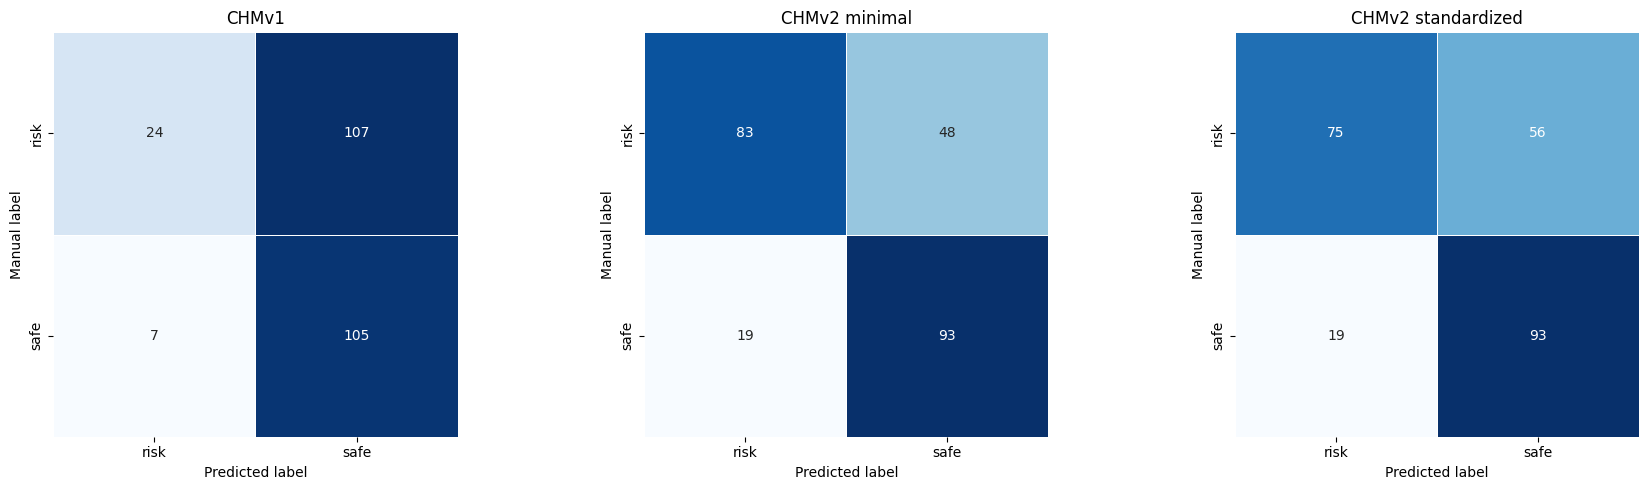

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

items = [
    ("CHMv1", cm_chmv1),
    ("CHMv2 minimal", cm_chmv2_min),
    ("CHMv2 standardized", cm_chmv2_std),
]

for ax, (title, cm) in zip(axes, items):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        square=True,
        linewidths=0.5,
        linecolor="white"
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Manual label")

plt.tight_layout()
plt.show()


In [ ]:
def classification_metrics(cm):
    tp = cm.loc["risk", "risk"]
    fn = cm.loc["risk", "safe"]
    fp = cm.loc["safe", "risk"]
    tn = cm.loc["safe", "safe"]

    total = tp + fn + fp + tn

    accuracy = (tp + tn) / total if total else np.nan
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan

    return {
        "TP_risk": tp,
        "FN_risk": fn,
        "FP_risk": fp,
        "TN_risk": tn,
        "accuracy": accuracy,
        "precision_risk": precision,
        "recall_risk": recall,
        "specificity_safe": specificity,
        "f1_risk": f1,
        "n_used": total,
    }

metrics_df = pd.DataFrame([
    {"model": "CHMv1", **classification_metrics(cm_chmv1)},
    {"model": "CHMv2 minimal", **classification_metrics(cm_chmv2_min)},
    {"model": "CHMv2 standardized", **classification_metrics(cm_chmv2_std)},
])

metrics_df


,model,TP_risk,FN_risk,FP_risk,TN_risk,accuracy,precision_risk,recall_risk,specificity_safe,f1_risk,n_used
0,CHMv1,24,107,7,105,0.530864,0.774194,0.183206,0.937500,0.296296,243
1,CHMv2 minimal,83,48,19,93,0.724280,0.813725,0.633588,0.830357,0.712446,243
2,CHMv2 standardized,75,56,19,93,0.691358,0.797872,0.572519,0.830357,0.666667,243


In [ ]:
metrics_pct = metrics_df.copy()

for col in ["accuracy", "precision_risk", "recall_risk", "specificity_safe", "f1_risk"]:
    metrics_pct[col] = (metrics_pct[col] * 100).round(2)

metrics_pct


,model,TP_risk,FN_risk,FP_risk,TN_risk,accuracy,precision_risk,recall_risk,specificity_safe,f1_risk,n_used
0,CHMv1,24,107,7,105,53.09,77.42,18.32,93.75,29.63,243
1,CHMv2 minimal,83,48,19,93,72.43,81.37,63.36,83.04,71.24,243
2,CHMv2 standardized,75,56,19,93,69.14,79.79,57.25,83.04,66.67,243


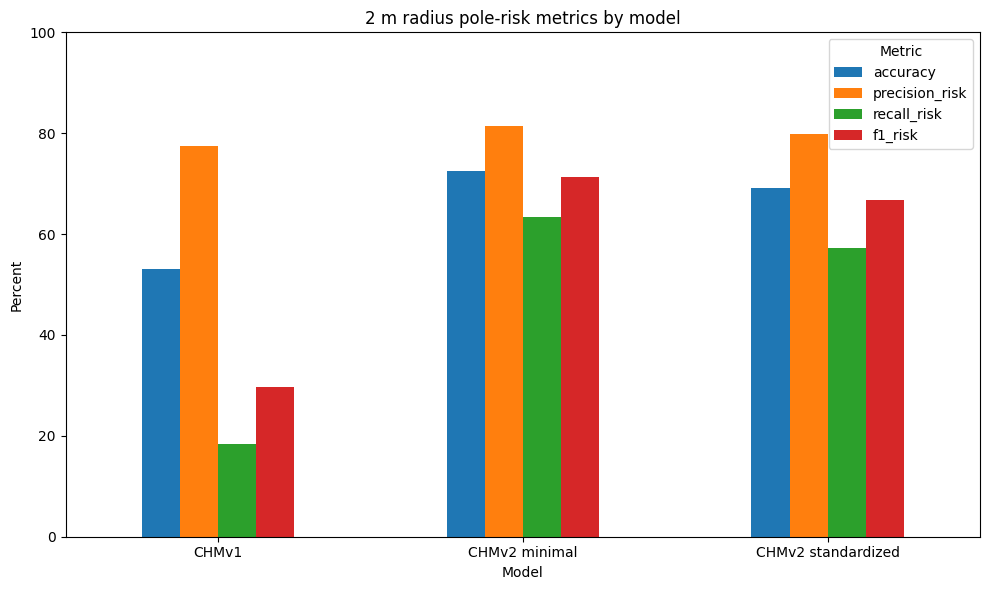

In [ ]:
plot_df = metrics_pct.set_index("model")[["accuracy", "precision_risk", "recall_risk", "f1_risk"]]

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("2 m radius pole-risk metrics by model")
plt.ylabel("Percent")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


In [ ]:
radius_stats = pd.DataFrame([
    {
        "model": "CHMv1",
        "mean_buffer_max_m": df["chmv1_buffer_max_m"].mean(),
        "mean_buffer_mean_m": df["chmv1_buffer_mean_m"].mean(),
        "mean_buffer_p95_m": df["chmv1_buffer_p95_m"].mean(),
        "mean_above_pole_pct": df["chmv1_buffer_above_pole_pct"].mean(),
    },
    {
        "model": "CHMv2 minimal",
        "mean_buffer_max_m": df["chmv2_min_buffer_max_m"].mean(),
        "mean_buffer_mean_m": df["chmv2_min_buffer_mean_m"].mean(),
        "mean_buffer_p95_m": df["chmv2_min_buffer_p95_m"].mean(),
        "mean_above_pole_pct": df["chmv2_min_buffer_above_pole_pct"].mean(),
    },
    {
        "model": "CHMv2 standardized",
        "mean_buffer_max_m": df["chmv2_std_buffer_max_m"].mean(),
        "mean_buffer_mean_m": df["chmv2_std_buffer_mean_m"].mean(),
        "mean_buffer_p95_m": df["chmv2_std_buffer_p95_m"].mean(),
        "mean_above_pole_pct": df["chmv2_std_buffer_above_pole_pct"].mean(),
    },
])

radius_stats.round(3)


,model,mean_buffer_max_m,mean_buffer_mean_m,mean_buffer_p95_m,mean_above_pole_pct
0,CHMv1,2.895,2.000,2.751,8.260
1,CHMv2 minimal,8.597,5.926,8.182,29.864
2,CHMv2 standardized,7.761,5.585,7.439,29.909


In [ ]:
output_csv = Path("/content/drive/MyDrive/electric-pole-analysis/outputs/pole_radius_analysis_results_2m.csv")

df.to_csv(output_csv, index=False)
print("Saved:", output_csv)


Saved: /content/drive/MyDrive/electric-pole-analysis/outputs/pole_radius_analysis_results_2m.csv


In [ ]:
best_accuracy = metrics_df.loc[metrics_df["accuracy"].idxmax(), "model"]
best_precision = metrics_df.loc[metrics_df["precision_risk"].idxmax(), "model"]
best_recall = metrics_df.loc[metrics_df["recall_risk"].idxmax(), "model"]
best_f1 = metrics_df.loc[metrics_df["f1_risk"].idxmax(), "model"]

print("Best accuracy:", best_accuracy)
print("Best precision for risk:", best_precision)
print("Best recall for risk:", best_recall)
print("Best F1 for risk:", best_f1)

print("\nRecommended model for pole vegetation analysis:")
print("- Prefer the model with the strongest recall_risk and F1_risk.")
print("- Recall is especially important because missing risky poles is costly.")


Best accuracy: CHMv2 minimal
Best precision for risk: CHMv2 minimal
Best recall for risk: CHMv2 minimal
Best F1 for risk: CHMv2 minimal

Recommended model for pole vegetation analysis:
- Prefer the model with the strongest recall_risk and F1_risk.
- Recall is especially important because missing risky poles is costly.
